In [39]:
import torchvision as thv

from common.nn.dataset.nn_dataset import NNDataset

from common.nn.enum.nets import Nets
from common.nn.enum.losses import Losses
from common.nn.enum.devices import Devices

from common.nn.params.nn_run import NNRun
from common.nn.params.nn_params import NNParams
from common.nn.params.nn_train_params import NNTrainParams
from common.nn.params.nn_model_params import NNModelParams

from common.nn.nn_model import NNModel

from common.utils import Utils
from common.vis_utils import VisUtils

In [40]:
DS_MEAN : float = 0.1307
DS_STD  : float = 0.3081

ds = NNDataset(
    ds_class=thv.datasets.MNIST
    , transform=thv.transforms.Compose(
        [
            thv.transforms.ToTensor()
            , thv.transforms.Normalize(mean=DS_MEAN, std=DS_STD)
        ]
    )
)

Utils.print_table(
    header=False
    , data=ds.state()
    , title='Dataset Details...'
)

+---------------------------+
|     Dataset Details...    |
+------------------+--------+
|       name       | MNIST  |
|    input_dim     |  784   |
|    output_dim    |   10   |
| train_batch_size | 60,000 |
|  val_batch_size  | 1,000  |
| test_batch_size  | 9,000  |
+------------------+--------+


In [4]:
n_epochs = 500
optims = ["adam"]

dropout_probs = [0.25, 0.5]
hidden_dimss = [
    []
    , [128]
    , [256]
    , [512]
    , [256, 128]
    , [256, 128, 64]
    , [512, 256]
    , [512, 256, 128]
    , [512, 256, 128, 64]
]

models = [
    model
        for model in [
            NNModel(
                params=NNModelParams(
                    net=Nets.FEED_FWD
                    , device=Devices.MPS
                    , loss=Losses.CROSS_ENTROPY
                )
                , net_params=NNParams(
                    dropout_prob=dropout_prob
                    , hidden_dims=hidden_dims
                    , input_dim=ds.input_dim
                    , output_dim=ds.output_dim
                )
            )
                for dropout_prob in dropout_probs
                for hidden_dims in hidden_dimss
        ]
]

train_params = [
    train_param
        for train_param in [
            NNTrainParams(n_epochs=n_epochs)
                .with_train_loader(value=ds.train_loader)
                .with_val_loader(value=ds.val_loader)
        ]
]

runs = [
    run for run in [
        model.train(params=train_param)
            for model in models
            for train_param in train_params
    ]
]

+--------------------------------------------------------------+
|                        Run Details...                        |
+---------------------------+----------------------------------+
|             id            | 9cfbd40993d9af82b9fc323c58acc577 |
|         model.net         |             feed_fwd             |
|         model.loss        |          cross_entropy           |
|        model.device       |               mps                |
|       net.input_dim       |               784                |
|       net.output_dim      |                10                |
|      net.dropout_prob     |               0.25               |
|      net.hidden_dims      |                []                |
|       net.activation      |            leaky_relu            |
|       train.n_epochs      |               500                |
|     train.optim.max_lr    |               0.01               |
|    train.optim.momentum   |           (0.9, 0.999)           |
|      train.optim.name  

Training: 100%|██████████| 500/500 [22:28<00:00,  2.70s/it, error=0.0790, lr=0.0012]



+--------------------------------------------------------------+
|                        Run Details...                        |
+---------------------------+----------------------------------+
|             id            | 0d8ee7f23749f37749300ec4c7b865a8 |
|         model.net         |             feed_fwd             |
|         model.loss        |          cross_entropy           |
|        model.device       |               mps                |
|       net.input_dim       |               784                |
|       net.output_dim      |                10                |
|      net.dropout_prob     |               0.25               |
|      net.hidden_dims      |              [128]               |
|       net.activation      |            leaky_relu            |
|       train.n_epochs      |               500                |
|     train.optim.max_lr    |               0.01               |
|    train.optim.momentum   |           (0.9, 0.999)           |
|      train.optim.name 

Training: 100%|██████████| 500/500 [31:52<00:00,  3.83s/it, error=0.0320, lr=0.0016]



+--------------------------------------------------------------+
|                        Run Details...                        |
+---------------------------+----------------------------------+
|             id            | 1073f7b479c4c5dd86fdc2850c090e5b |
|         model.net         |             feed_fwd             |
|         model.loss        |          cross_entropy           |
|        model.device       |               mps                |
|       net.input_dim       |               784                |
|       net.output_dim      |                10                |
|      net.dropout_prob     |               0.25               |
|      net.hidden_dims      |              [256]               |
|       net.activation      |            leaky_relu            |
|       train.n_epochs      |               500                |
|     train.optim.max_lr    |               0.01               |
|    train.optim.momentum   |           (0.9, 0.999)           |
|      train.optim.name 

...

Training: 100%|██████████| 500/500 [35:44<00:00,  4.29s/it, error=0.0210, lr=0.0015]  



+--------------------------------------------------------------+
|                        Run Details...                        |
+---------------------------+----------------------------------+
|             id            | 9672b38dce81c2aaa7d946419cb6fdad |
|         model.net         |             feed_fwd             |
|         model.loss        |          cross_entropy           |
|        model.device       |               mps                |
|       net.input_dim       |               784                |
|       net.output_dim      |                10                |
|      net.dropout_prob     |               0.5                |
|      net.hidden_dims      |         [512, 256, 128]          |
|       net.activation      |            leaky_relu            |
|       train.n_epochs      |               500                |
|     train.optim.max_lr    |               0.01               |
|    train.optim.momentum   |           (0.9, 0.999)           |
|      train.optim.name 

Training: 100%|██████████| 500/500 [48:47<00:00,  5.85s/it, error=0.0190, lr=0.0014]    



+--------------------------------------------------------------+
|                        Run Details...                        |
+---------------------------+----------------------------------+
|             id            | 34fcc9e8970154558e5e4ecbc559c859 |
|         model.net         |             feed_fwd             |
|         model.loss        |          cross_entropy           |
|        model.device       |               mps                |
|       net.input_dim       |               784                |
|       net.output_dim      |                10                |
|      net.dropout_prob     |               0.5                |
|      net.hidden_dims      |       [512, 256, 128, 64]        |
|       net.activation      |            leaky_relu            |
|       train.n_epochs      |               500                |
|     train.optim.max_lr    |               0.01               |
|    train.optim.momentum   |           (0.9, 0.999)           |
|      train.optim.name 

Training: 100%|██████████| 500/500 [36:58<00:00,  4.44s/it, error=0.0220, lr=0.0015] 

In [41]:
top_runs = [
    run for run in sorted(
        NNRun.all()
        , key=lambda run: min(
            run.idps, key=lambda idp: idp.val_edp.error
        ).val_edp.error
    )[:5]
]

In [4]:
VisUtils.multi_line_plot(
    x_ticks_inc=25
    , y_axis_label="Error"
    , x_axis_label="Iterations"
    , title=f"Training & Validation Errors"
    , fig_size=(16 * 100 * 1.5, 9 * 100 * 1.5)
    , x=[
        iter_idx for iter_idx in range(
            0
            , max(
                top_runs
                , key=lambda run: run.idps[-1].iter_idx
            ).idps[-1].iter_idx
        )
    ]
    , yss_legend=[
        ['Training', 'Validation']
        , [str(run) for run in top_runs]
    ]
    , yss=[
        [
            [idp.train_edp.error for idp in run.idps]
            , [idp.val_edp.error for idp in run.idps]
        ] for run in top_runs
    ]
)

In [5]:
VisUtils.multi_line_plot(
    x_ticks_inc=25
    , y_axis_label="LR"
    , x_axis_label="Iterations"
    , title=f"Learning Rates"
    , fig_size=(16 * 100 * 1.5, 9 * 100 * 1.5)
    , x=[
        iter_idx for iter_idx in range(
            0
            , max(
                top_runs
                , key=lambda run: run.idps[-1].iter_idx
            ).idps[-1].iter_idx
        )
    ]
    , yss_legend=[
        ['LR']
        , [str(run) for run in top_runs]
    ]
    , yss=[
        [
            [idp.lr for idp in run.idps]
        ] for run in top_runs
    ]
)

In [6]:
print(f"best run is {top_runs[0].id} which achieves validation error of {min(top_runs[0].idps, key=lambda idp: idp.val_edp.error).val_edp.error:.4f}")

best run is 01d915cb2eb783038a4edc78a05a815d which achieves validation error of 0.0160


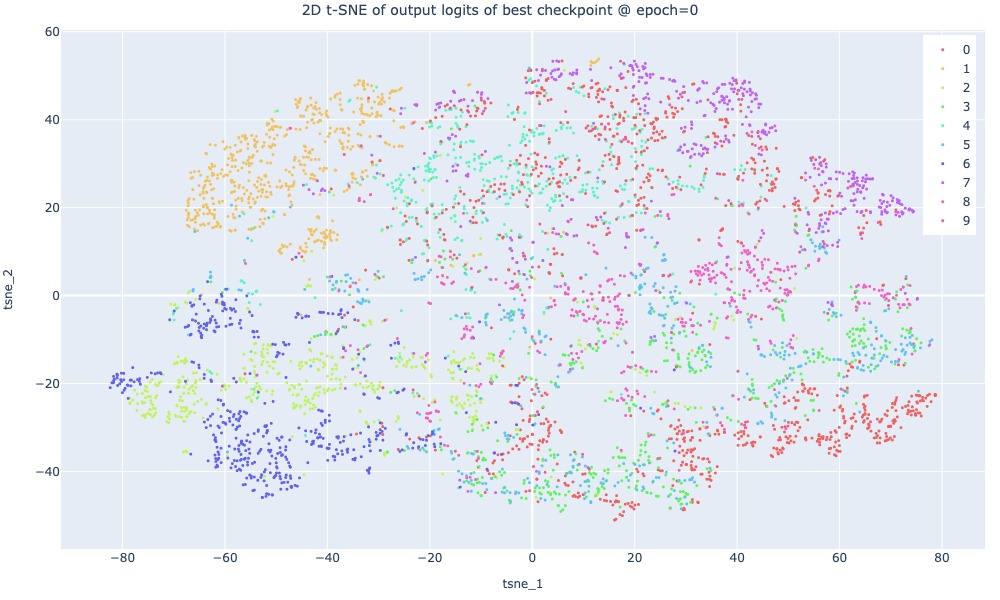

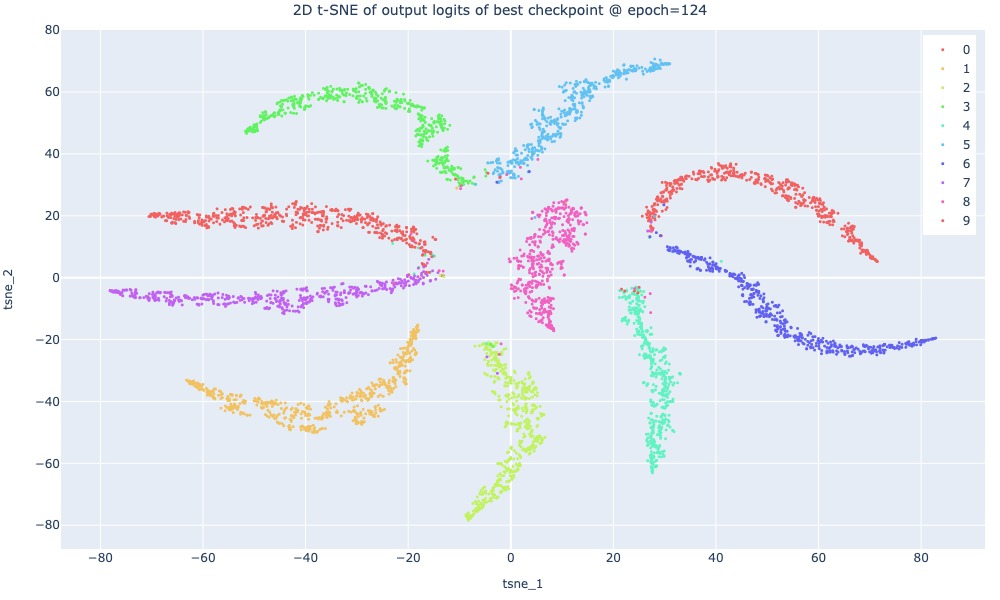

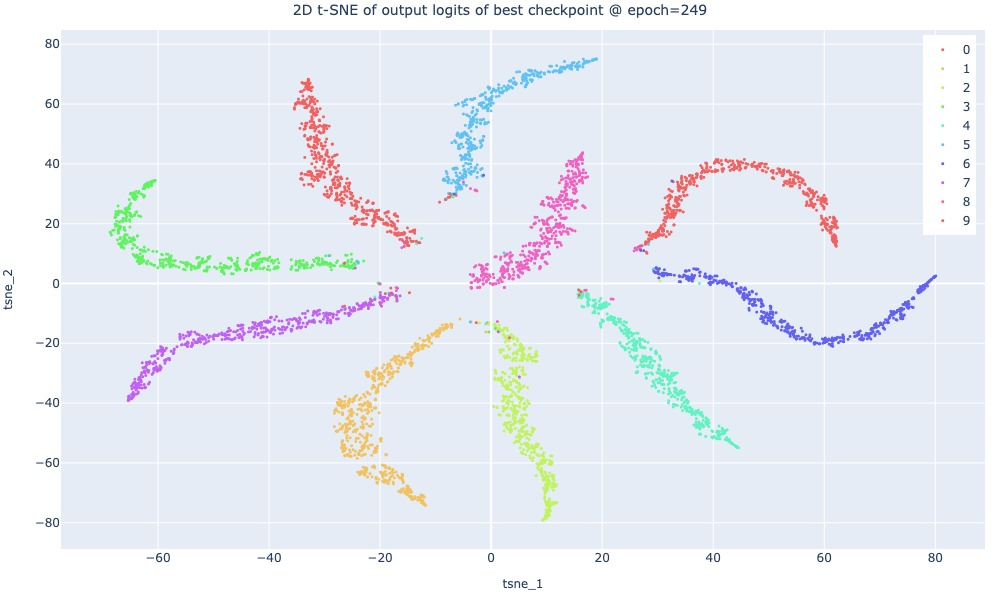

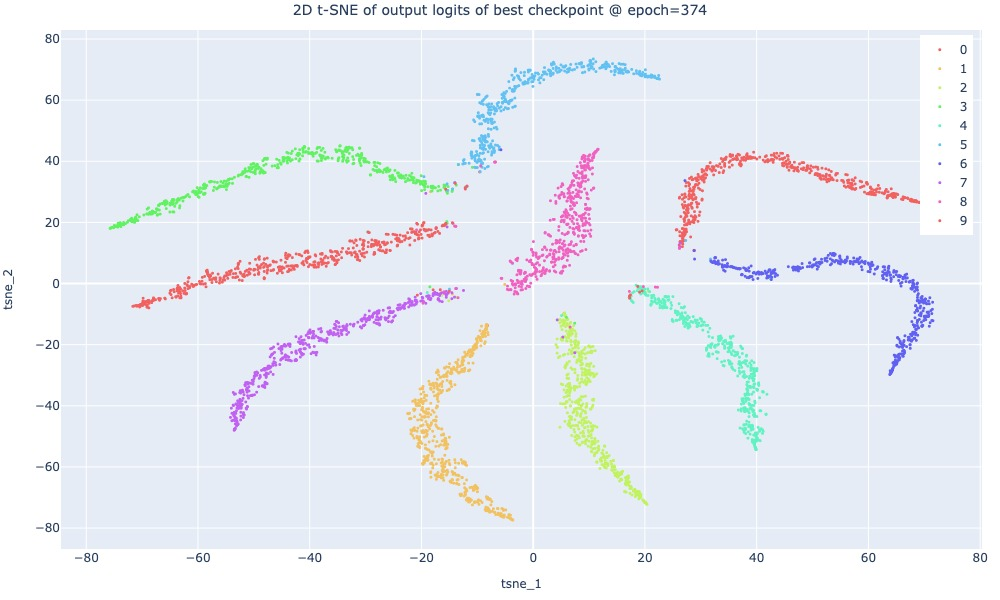

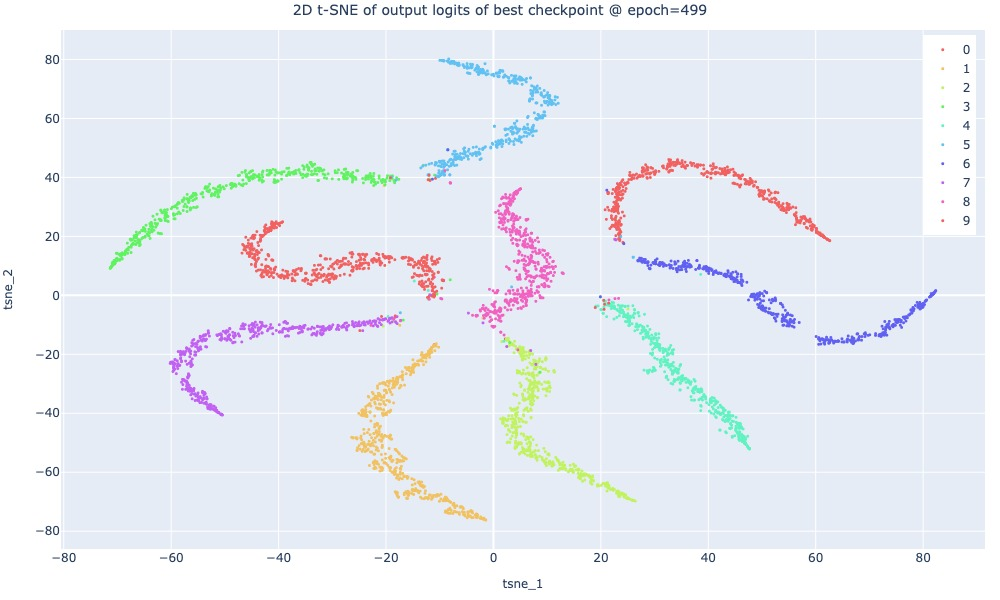

In [35]:
N_SAMPLES = 5_000

for checkpoint in NNRun.load("best").checkpoints():
    VisUtils.two_dim_tsne_checkpoint_logits(checkpoint=checkpoint, ds=ds, n_samples=N_SAMPLES, renderer="jpg")

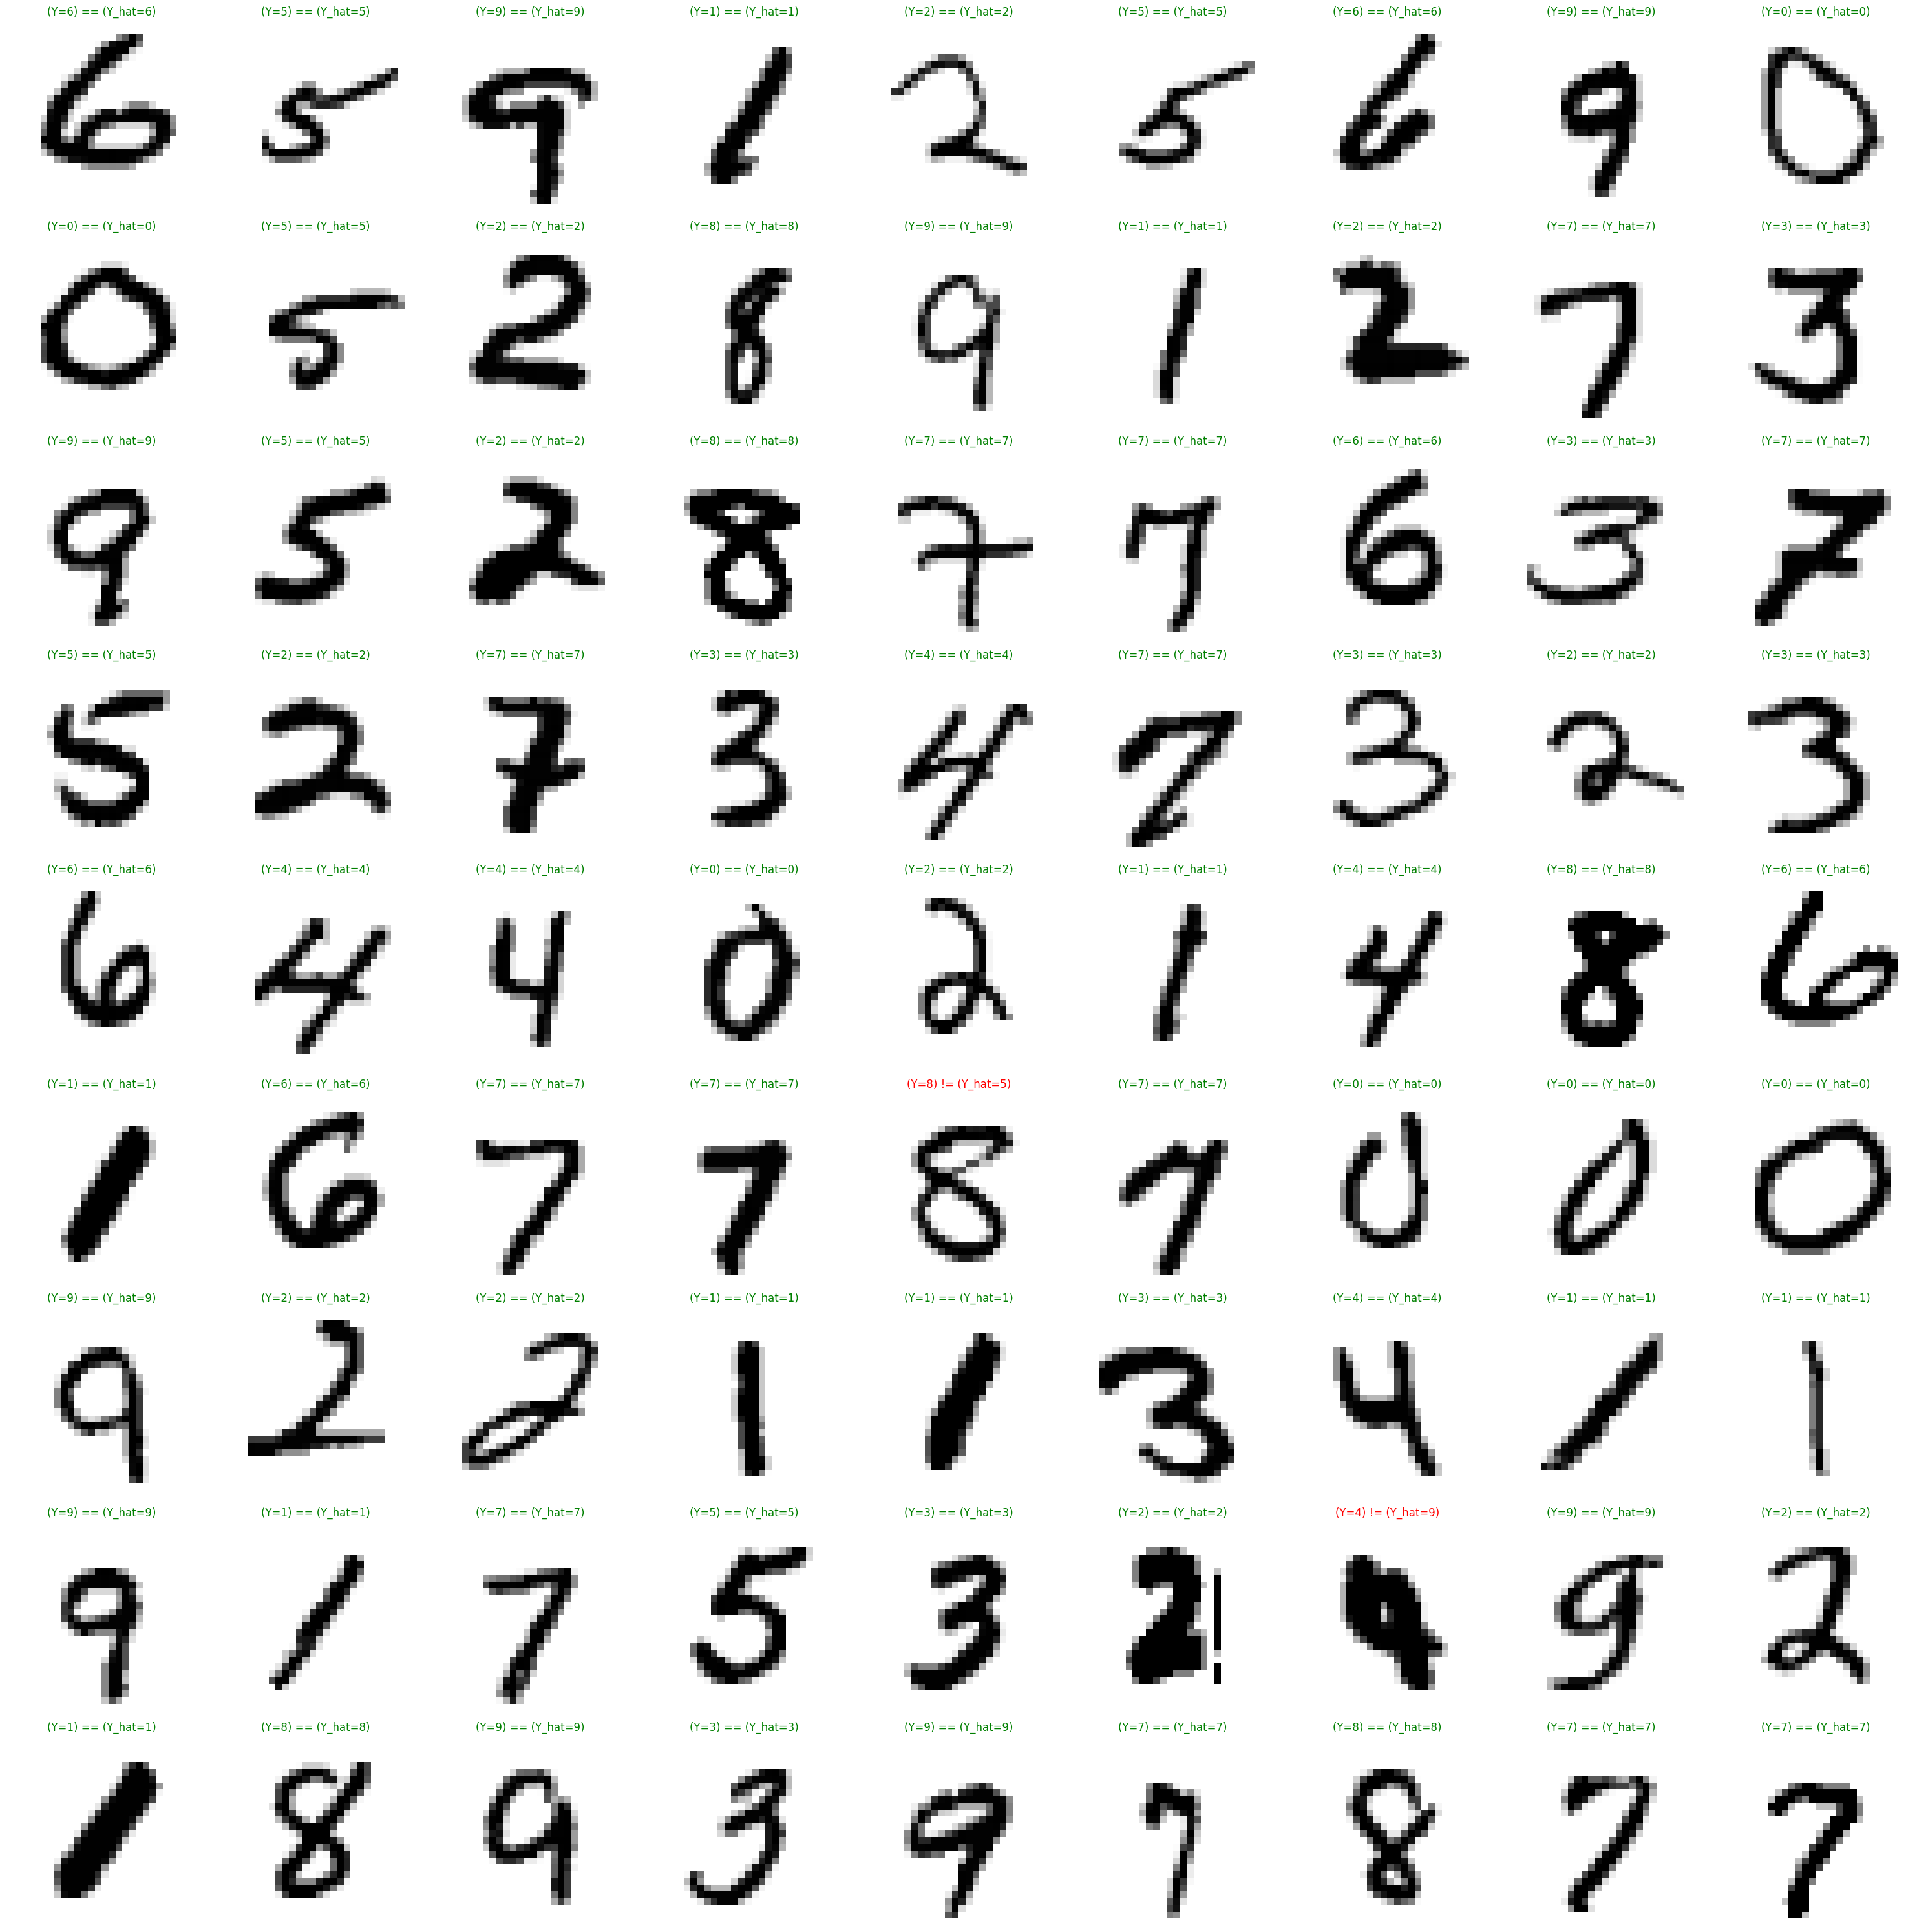

In [38]:
import math
import matplotlib.pyplot as plt

model = NNModel.from_checkpoint(checkpoint=NNRun.load("best").checkpoints()[-1])

test_batch = next(iter(ds.test_loader))
test_X, test_Y = model.net.unpack_batch(test_batch)
test_X, test_Y = tuple(x.numpy() for x in test_X), test_Y.numpy()
test_Y_hat = model.predict(X=test_X)

N_SAMPLES = 81
_, axes = plt.subplots(
    figsize=(30, 30)
    , nrows=int(math.sqrt(N_SAMPLES))
    , ncols=int(math.sqrt(N_SAMPLES))
)
axes = axes.ravel()

for ax, X, Y, Y_hat in zip(axes, test_X[0][:N_SAMPLES], test_Y[:N_SAMPLES], test_Y_hat[1][:N_SAMPLES]):
    ax.set_axis_off()
    ax.imshow(X.reshape(28, 28), cmap=plt.cm.gray_r, interpolation="nearest")
    
    ax.set_title(
        f"(Y={Y}) {'==' if Y_hat == Y else '!='} (Y_hat={Y_hat})"
        , color="green" if Y_hat == Y else "red"
    )
    
plt.tight_layout()
plt.show()